# Saudi Digital Concierge — Data Exploration
## Source 4: DataSaudi — Tourism Indicators (11 datasets)

**Folder:** `data/raw/tourism_statistics/tourism_statistics_datasaudi/`
**Purpose:** official tourism statistics — length of stay, spending, overnight stays,
trip purpose, sentiment (NPS / satisfaction), hotel occupancy, and macro indicators.

These are *supporting statistical context* for the concierge (not core conversational
content). This notebook profiles all 11 files, groups them by theme, charts the useful
signals, and ends with cleaning + curation recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

BASE = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
DIR = BASE / "data" / "raw" / "tourism_statistics" / "tourism_statistics_datasaudi"

files = sorted(p.name for p in DIR.glob("*.csv"))
data = {f: pd.read_csv(DIR / f) for f in files}
print(f"Loaded {len(data)} files from {DIR}")
files

Loaded 11 files from /home/user/saudi-Digital-Concierge/data/raw/tourism_statistics/tourism_statistics_datasaudi


['mot_average_length_of_stay_by_tourists_type.csv',
 'mot_average_spending_per_night_by_tourists_type.csv',
 'mot_average_spending_per_trip_by_tourists_type.csv',
 'mot_number_of_overnight_stays_by_tourists_type.csv',
 'mot_tourism_by_trip_main_purpose_and_tourists_type.csv',
 'net_promoter_score.csv',
 'sama_tourism_expenditure_by_trip_purpose_and_tourists_type.csv',
 'tourism_complementary_indicators.csv',
 'tourism_occupancy_rate_monthly.csv',
 'tourism_occupancy_rate_yearly.csv',
 'tourism_satisfaction_index.csv']

## 1. Manifest — what's in each file

A quick overview: rows, columns, and the year/quarter coverage of every dataset.

In [2]:
rows = []
for name, df in data.items():
    yr = ""
    if "Year" in df:
        yr = f"{int(df['Year'].min())}-{int(df['Year'].max())}"
    elif "Quarter" in df:
        yr = f"{df['Quarter'].min()}..{df['Quarter'].max()}"
    rows.append({
        "file": name.replace(".csv", ""),
        "rows": len(df),
        "cols": df.shape[1],
        "coverage": yr,
        "duplicates": int(df.duplicated().sum()),
        "missing": int(df.isna().sum().sum()),
    })
manifest = pd.DataFrame(rows)
manifest

,file,rows,cols,coverage,duplicates,missing
0,mot_average_length_of_stay_by_tourists_type,49,8,2015-2025,0,0
1,mot_average_spending_per_night_by_tourists_type,49,8,2015-2025,0,0
2,mot_average_spending_per_trip_by_tourists_type,49,8,2015-2025,0,0
3,mot_number_of_overnight_stays_by_tourists_type,49,8,2015-2025,0,0
4,mot_tourism_by_trip_main_purpose_and_tourists_...,127,8,2015-2025,0,0
5,net_promoter_score,6,5,2024-Q2..2025-Q3,0,0
6,sama_tourism_expenditure_by_trip_purpose_and_t...,126,8,2014-2022,0,0
7,tourism_complementary_indicators,6,24,2019-2024,0,0
8,tourism_occupancy_rate_monthly,1392,8,2021-2024,0,0
9,tourism_occupancy_rate_yearly,116,6,2021-2024,0,0


### Shared schema notes
- Every file is the `Tourism` economic sector (`Economic Sectors ID = Z`) — that column
  is constant and can be dropped.
- Files carry redundant `*_ID` columns paired with their human-readable label
  (`Nationality ID`/`Nationality`, `Tourist Type Name ID`/`Tourist Type Name`, etc.).
- **New dimensions** not present in Source 3: `Outbound` tourist type, `Nationality`
  (Saudi / Non Saudi / Total), `Trip Purpose`, `Accommodation Type`, and quarterly sentiment.
- **Data quality is good**: 0 duplicates and 0 missing values across all 11 files.

## 2. Group A — Metrics by tourist type
`length of stay`, `spending per night`, `spending per trip`, `overnight stays`.
Each has Year × Tourist Type (Domestic / Inbound / Outbound) × Nationality.

In [3]:
groupA = {
    "Avg length of stay (nights)":  ("mot_average_length_of_stay_by_tourists_type.csv", "Night"),
    "Avg spend / night (SAR)":      ("mot_average_spending_per_night_by_tourists_type.csv", "SAR"),
    "Avg spend / trip (SAR)":       ("mot_average_spending_per_trip_by_tourists_type.csv", "SAR"),
    "Overnight stays":              ("mot_number_of_overnight_stays_by_tourists_type.csv", "Overnight Stays"),
}
for title, (fn, col) in groupA.items():
    df = data[fn]
    piv = df.pivot_table(index="Year", columns="Tourist Type Name", values=col, aggfunc="mean")
    print("\n===", title, "===")
    print(piv.round(1).to_string())


=== Avg length of stay (nights) ===
Tourist Type Name  Domestic  Inbound  Outbound
Year                                          
2015                    5.1     10.4      16.3
2016                    5.2      9.9      15.4
2017                    5.1      9.5      14.8
2018                    5.3     10.1      14.2
2019                    5.6      9.8      15.5
2020                    5.3      5.9      18.3
2021                    5.4      8.6      15.3
2022                    4.6     16.6      11.0
2023                    5.9     15.6      18.9
2024                    6.1     19.2       NaN
2025                    6.0     18.9       NaN

=== Avg spend / night (SAR) ===
Tourist Type Name  Domestic  Inbound  Outbound
Year                                          
2015                  204.6    456.9     327.1
2016                  237.2    517.8     373.3
2017                  208.9    588.9     312.8
2018                  209.0    566.2     311.9
2019                  224.1    544.0 

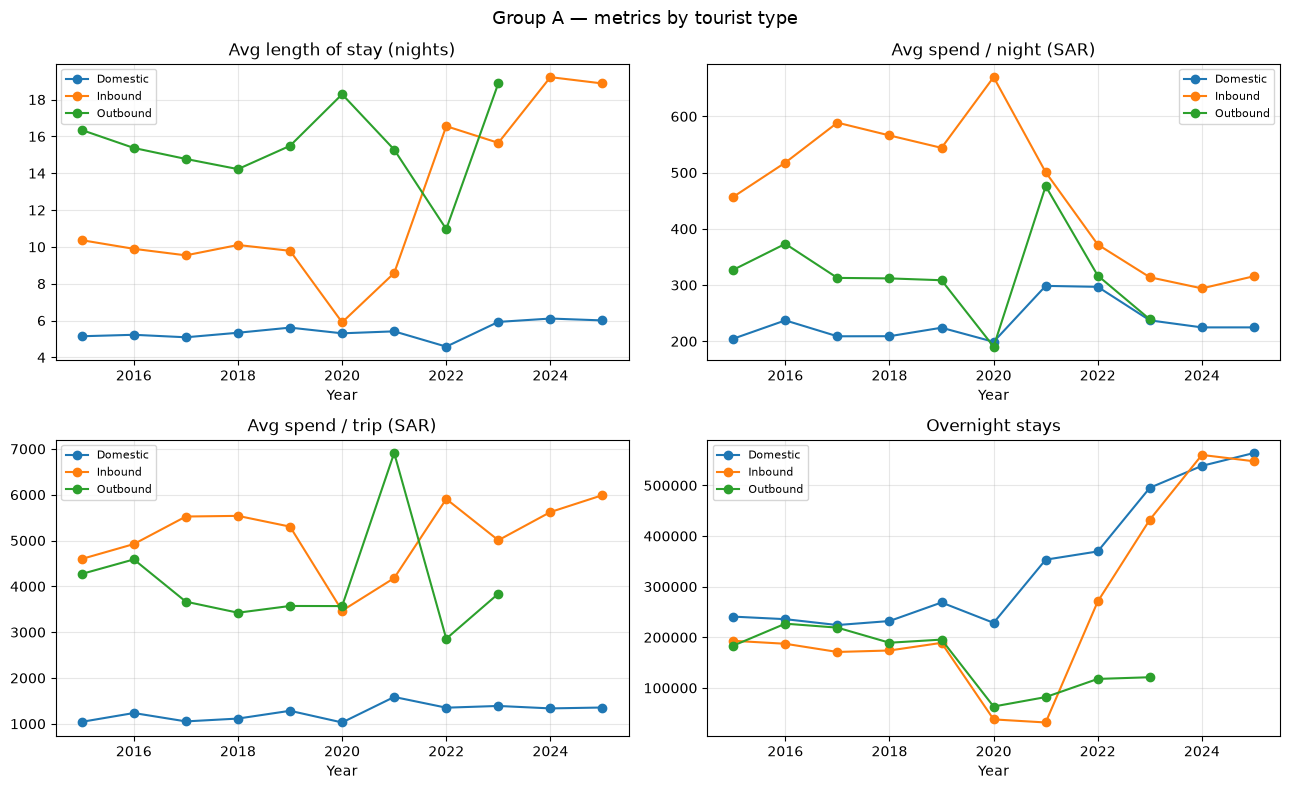

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (title, (fn, col)) in zip(axes.ravel(), groupA.items()):
    df = data[fn]
    piv = df.pivot_table(index="Year", columns="Tourist Type Name", values=col, aggfunc="mean")
    piv.plot(marker="o", ax=ax)
    ax.set_title(title); ax.set_xlabel("Year"); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, title="")
fig.suptitle("Group A — metrics by tourist type", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Group B — By purpose of visit
`tourists by trip purpose` (MoT) and `expenditure by trip purpose` (SAMA).
Purpose of visit is the most concierge-relevant new dimension here.

Tourists by purpose — 2025 (Nationality = Total):
Trip Purpose Name
Visiting Friends & Relatives    42028.7
Leisure                         37255.2
Religious                       27933.3
Business                        10785.0
Other                            4576.0
Name: Tourists, dtype: float64


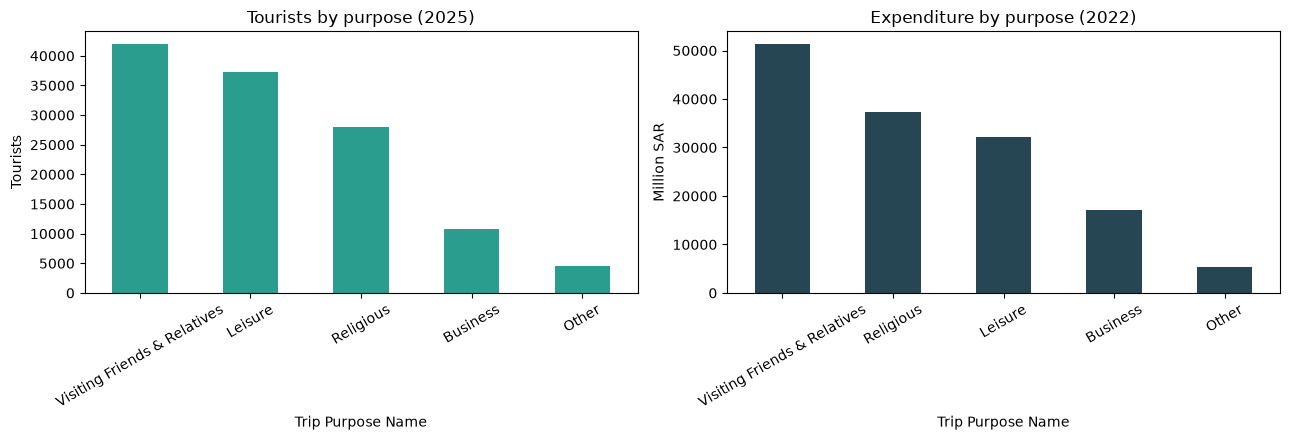

In [5]:
purpose = data["mot_tourism_by_trip_main_purpose_and_tourists_type.csv"]
latest = purpose["Year"].max()
tot = purpose[(purpose["Year"] == latest) & (purpose["Nationality"] == "Total")]
by_purpose = tot.groupby("Trip Purpose Name")["Tourists"].sum().sort_values(ascending=False)
print(f"Tourists by purpose — {int(latest)} (Nationality = Total):")
print(by_purpose.round(1))

spend = data["sama_tourism_expenditure_by_trip_purpose_and_tourists_type.csv"]
ly = spend["Year"].max()
spend_p = spend[spend["Year"] == ly].groupby("Trip Purpose Name")["Million SAR"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
by_purpose.plot(kind="bar", ax=axes[0], color="#2a9d8f")
axes[0].set_title(f"Tourists by purpose ({int(latest)})"); axes[0].set_ylabel("Tourists")
spend_p.plot(kind="bar", ax=axes[1], color="#264653")
axes[1].set_title(f"Expenditure by purpose ({int(ly)})"); axes[1].set_ylabel("Million SAR")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 4. Group C — Sentiment (quarterly)
`Net Promoter Score` and `Tourism Satisfaction Index`. Small (6 rows each) but unique —
these do not exist in any other source.

Net Promoter Score:
 Quarter  Net Promoter Score
2024-Q2                70.0
2024-Q3                68.0
2024-Q4                70.0
2025-Q1                76.0
2025-Q2                77.0
2025-Q3                71.0

Tourism Satisfaction Index:
 Quarter  Tourism Satisfaction Index
2024-Q2                        0.64
2024-Q3                        0.63
2024-Q4                        0.60
2025-Q1                        0.65
2025-Q2                        0.61
2025-Q3                        0.61


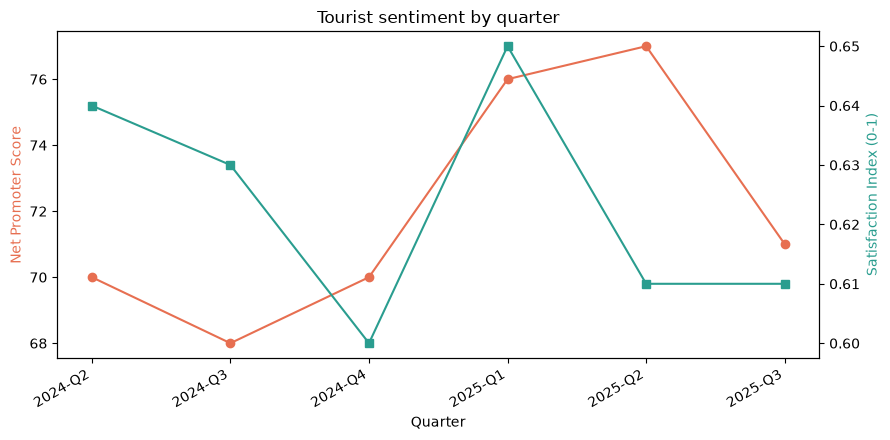

In [6]:
nps = data["net_promoter_score.csv"]
sat = data["tourism_satisfaction_index.csv"]
print("Net Promoter Score:\n", nps[["Quarter", "Net Promoter Score"]].to_string(index=False))
print("\nTourism Satisfaction Index:\n", sat[["Quarter", "Tourism Satisfaction Index"]].to_string(index=False))

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(nps["Quarter"], nps["Net Promoter Score"], marker="o", color="#e76f51", label="NPS")
ax1.set_ylabel("Net Promoter Score", color="#e76f51"); ax1.set_xlabel("Quarter")
ax2 = ax1.twinx()
ax2.plot(sat["Quarter"], sat["Tourism Satisfaction Index"], marker="s", color="#2a9d8f", label="Satisfaction")
ax2.set_ylabel("Satisfaction Index (0-1)", color="#2a9d8f")
ax1.set_title("Tourist sentiment by quarter")
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

## 5. Group D — Hotel occupancy
`yearly` (116 rows) and `monthly` (1,392 rows), by province and accommodation type.

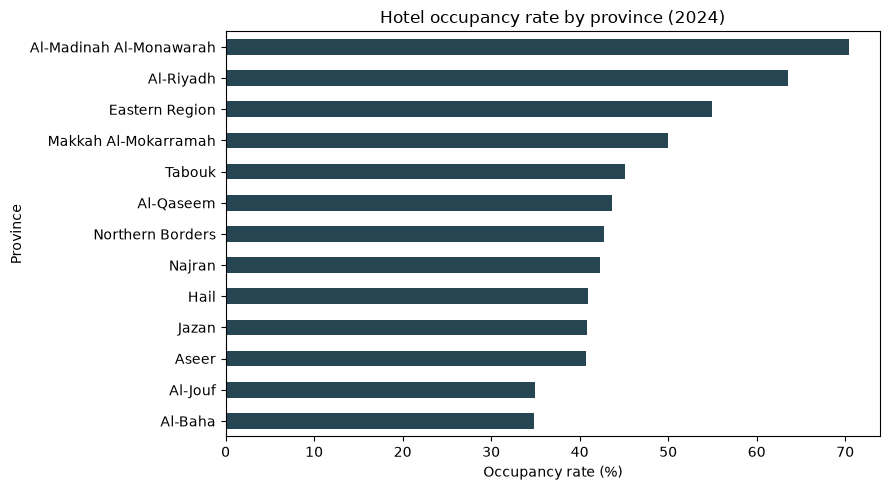

Province
Al-Madinah Al-Monawarah    70.4
Al-Riyadh                  63.5
Eastern Region             55.0
Makkah Al-Mokarramah       50.0
Tabouk                     45.1
Al-Qaseem                  43.7
Northern Borders           42.8
Najran                     42.3
Hail                       40.9
Jazan                      40.8
Aseer                      40.7
Al-Jouf                    35.0
Al-Baha                    34.8
Name: Occupancy Rate, dtype: float64

In [7]:
occ_y = data["tourism_occupancy_rate_yearly.csv"]
latest_y = occ_y["Year"].max()
# Hotels only, real provinces (exclude the 'Grand Total' rollup)
hy = occ_y[(occ_y["Year"] == latest_y) &
           (occ_y["Accommodation Type"] == "Hotels") &
           (occ_y["Province"] != "Grand Total")]
by_prov = hy.set_index("Province")["Occupancy Rate"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
(by_prov * 100).plot(kind="barh", ax=ax, color="#264653")
ax.invert_yaxis()
ax.set_title(f"Hotel occupancy rate by province ({int(latest_y)})")
ax.set_xlabel("Occupancy rate (%)")
plt.tight_layout()
plt.show()
(by_prov * 100).round(1)

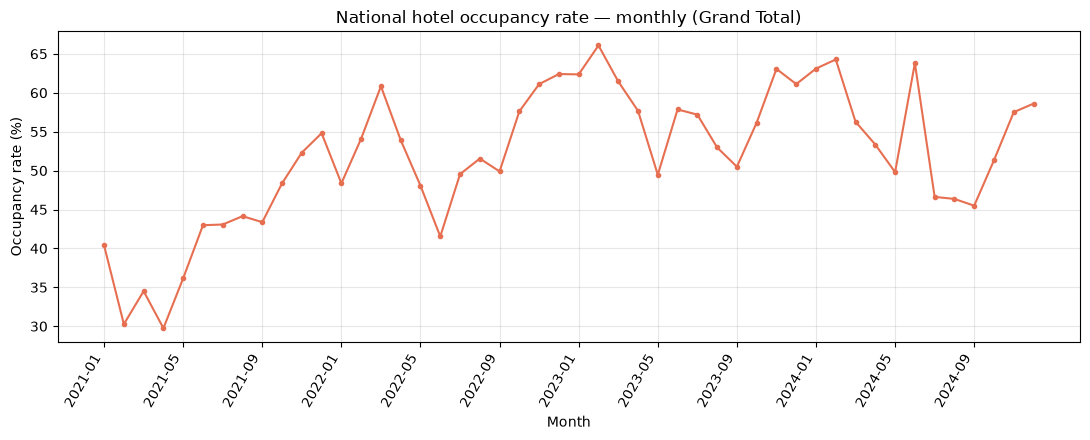

In [8]:
occ_m = data["tourism_occupancy_rate_monthly.csv"].copy()
nat = occ_m[(occ_m["Province"] == "Grand Total") & (occ_m["Accommodation Type"] == "Hotels")]
nat = nat.sort_values("Month ID")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(nat["Month"], nat["Occupancy Rate"] * 100, marker=".", color="#e76f51")
ax.set_title("National hotel occupancy rate — monthly (Grand Total)")
ax.set_ylabel("Occupancy rate (%)"); ax.set_xlabel("Month")
step = max(1, len(nat) // 12)
ax.set_xticks(range(0, len(nat), step))
fig.autofmt_xdate(rotation=60)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Group E — Complementary indicators (annual, wide)
24 macro ratios (tourism share of GDP, employment share, openness, ...), 2019–2024.
Very wide and analytical — low direct value for a concierge, but a useful summary.

In [9]:
ind = data["tourism_complementary_indicators.csv"]
cols = ["Year", "Gross Travel Propensity", "Tourism Direct Contribution to GDP",
        "Tourism Contribution to Non-Oil GVA", "Tourism Coverage"]
ind[cols].round(3)

,Year,Gross Travel Propensity,Tourism Direct Contribution to GDP,Tourism Contribution to Non-Oil GVA,Tourism Coverage
0,2019,2.077,0.036,0.053,1.209
1,2020,1.525,0.016,0.021,0.495
2,2021,2.290,0.025,0.034,0.353
3,2022,3.151,0.035,0.057,1.514
4,2023,3.040,0.044,0.063,1.483
5,2024,3.120,0.049,0.066,1.461


## 7. Findings & recommendations

**Coverage & quality**
- 11 files, ~1,915 rows (1,392 of them the monthly occupancy series).
- Clean: **0 duplicates, 0 missing** across all files.
- Year coverage varies by file: most 2015–2025; SAMA expenditure 2014–2022; occupancy
  2021–2024; complementary indicators 2019–2024; sentiment quarterly 2024-Q2 → 2025-Q3.

**New dimensions vs Source 3**
- `Outbound` tourist type, `Nationality` (Saudi / Non Saudi / Total), `Trip Purpose`
  (Business / Leisure / Religious / Visiting Friends & Relatives / Other),
  `Accommodation Type`, and quarterly **sentiment** (NPS ~68–77, Satisfaction ~0.60–0.65).

**Cleaning (for `src/cleaning`)**
1. Drop constant / redundant columns: `Economic Sectors*` (always Tourism) and every
   `*_ID` column that pairs a label.
2. **Harmonise province names** across sources — DataSaudi uses `Al-Riyadh`,
   `Makkah Al-Mokarramah`; Source 3 uses `Riyadh`, `Makkah`. Build one canonical key.
3. Exclude `Grand Total` rollup rows before aggregating (they are subtotals, not data).
4. Record units per file (nights, SAR, Million SAR, ratio 0–1) in the schema.

**Curation for the concierge (RAG)**
- ✅ Keep: trip-purpose (tourists + expenditure), NPS, satisfaction, complementary
  indicators — distinct, small, user-relevant.
- ❌ Redundant with Source 3: length of stay, spend/night, spend/trip, overnight stays.
- ❌ Heavy / operational: monthly occupancy (1,392 rows) — keep only the yearly rollup.

**Next step:** clean and write curated tables to `data/processed/`, then embed the
concierge-relevant ones (purpose of visit, sentiment) into the vector store.